# Bloque 3 — Demo: Ollama de punta a punta

Este notebook acompaña la Sección 2 y 3 de la presentación del Bloque 3 ("Ollama: el LLM que
corre en tu máquina" y "Entendiendo los modelos"). No repite el pipeline de análisis — eso
se ve en los notebooks de cada foro (Bloque 5) — sino que se queda en el terreno de este bloque:
instalar Ollama, entender qué hace por debajo, gestionar modelos (de la librería oficial y de
Hugging Face), y usar todo eso desde Python de forma desglosada, paso a paso, función por
función — al mismo nivel de detalle que `bloque1_bigdata/demo_bigdata.ipynb`.

**Cómo está pensado:** cada celda hace UNA sola cosa, para poder pararse y comentar cada
resultado antes de seguir. Los modelos que usa (`qwen3-embedding`, `qwen2.5:14b`) ya están
descargados en esta máquina de demo, así que las celdas de `ollama.pull(...)` corren rápido
(verifican el caché local, no vuelven a bajar nada). Al final del notebook hay tiempo reservado
para que cada uno pruebe con su propia máquina — sobre todo quien tenga GPU en su portátil
personal.

---

## 1. ¿Qué es Ollama, y qué hace por debajo?

Ollama es un **runtime de inferencia**: un programa que carga un modelo de lenguaje en memoria
(RAM o VRAM) y expone un servidor HTTP local para hablar con él. Cuando lo instalás, dos cosas
quedan corriendo:

1. Un **servicio en segundo plano** (`ollama serve`) escuchando en `http://localhost:11434`.
2. Un **CLI** (`ollama`) que es, en el fondo, un cliente de ese mismo servidor — `ollama run`,
   `ollama pull`, `ollama list` no hacen magia por su cuenta, mandan peticiones HTTP a
   `localhost:11434` igual que lo haría cualquier programa Python.

Esto es la pieza central de por qué este curso es viable con datos sensibles: ni un byte de lo
que le mandás al modelo sale de tu máquina. No hay API key, no hay tráfico de red hacia un
tercero — la petición nunca sale de `localhost`.

### Instalación

La instalación en sí **no se corre desde este notebook** — es un paso de sistema operativo,
antes de siquiera abrir Jupyter. Un único comando por plataforma:

```bash
# Linux / macOS
curl -fsSL https://ollama.com/install.sh | sh

# Windows: descargar el instalador desde https://ollama.com/download
```

Tras instalar, el servicio queda corriendo solo (en Linux como servicio `systemd`; en
macOS/Windows como app en la bandeja del sistema). No hace falta lanzarlo a mano salvo que lo
hayas parado — en ese caso, `ollama serve` en una terminal lo vuelve a levantar.

Las celdas de abajo asumen que Ollama ya está instalado y corriendo.

Primero, la versión del CLI instalado — sirve para confirmar que la instalación del paso
anterior funcionó.

In [1]:
import subprocess

result = subprocess.run(["ollama", "--version"], capture_output=True, text=True)
print(result.stdout.strip())

ollama version is 0.30.6


Ahora, que el **servidor** esté escuchando — es un chequeo distinto al de arriba: se puede
tener el CLI instalado y el servicio caído (por ejemplo, si `ollama serve` se cerró). Probamos
con la llamada más simple posible desde Python: `ollama.list()`, que solo pide la lista de
modelos instalados.

In [2]:
import ollama

try:
    modelos = ollama.list()
    print(f"Servidor Ollama activo — {len(modelos.models)} modelo(s) instalado(s).")
except Exception as e:
    print(f"No se pudo conectar al servidor Ollama: {e}")
    print("Si acaba de instalar Ollama, corra 'ollama serve' en una terminal aparte.")

Servidor Ollama activo — 3 modelo(s) instalado(s).


### Debajo del cliente Python: es solo HTTP

El paquete `ollama` de Python (`pip install ollama` / ya incluido vía `uv sync`) es un cliente
delgado: cada función (`ollama.list()`, `ollama.embed()`, `ollama.chat()`...) arma un JSON,
lo manda por HTTP a `localhost:11434`, y parsea la respuesta a un objeto Python.

Para que quede claro que no hay nada oculto, hacemos la **misma petición a mano**, en dos
pasos: primero con el cliente oficial, después con `requests` puro contra el mismo endpoint.

In [3]:
# Paso 1: la petición con el cliente oficial
texto = "descarga de tarjetas validadas, tasa de acierto 95%"

resp_cliente = ollama.embed(model="qwen3-embedding", input=texto)
vector_cliente = resp_cliente.embeddings[0]

print(f"Dimensión del vector: {len(vector_cliente)}")
print(f"Primeros 5 valores: {vector_cliente[:5]}")

Dimensión del vector: 4096
Primeros 5 valores: [0.02727918, -0.0017148518, -0.012216329, -0.019261727, -0.0020785483]


In [4]:
# Paso 2: la MISMA petición, pero armada a mano con requests — sin pasar por el paquete ollama
import requests

resp_http = requests.post(
    "http://localhost:11434/api/embed",
    json={"model": "qwen3-embedding", "input": texto},
)
vector_http = resp_http.json()["embeddings"][0]

print(f"Status HTTP: {resp_http.status_code}")
print(f"Claves del JSON de respuesta: {list(resp_http.json().keys())}")
print(f"Primeros 5 valores: {vector_http[:5]}")

Status HTTP: 200
Claves del JSON de respuesta: ['model', 'embeddings', 'total_duration', 'load_duration', 'prompt_eval_count']
Primeros 5 valores: [0.027585272, -0.0022439207, -0.012266275, -0.019274233, -0.0024586744]


In [5]:
# Paso 3: comparar los dos vectores
diferencia_maxima = max(abs(a - b) for a, b in zip(vector_cliente, vector_http))

print(f"Diferencia máxima entre ambos vectores: {diferencia_maxima:.6f}")
print(
    "Son dos llamadas independientes al mismo endpoint, no la misma respuesta cacheada — "
    "por eso no dan bit a bit idéntico (variación de punto flotante en la inferencia), "
    "pero la diferencia es mínima frente a la magnitud de los valores del vector."
)

Diferencia máxima entre ambos vectores: 0.003171
Son dos llamadas independientes al mismo endpoint, no la misma respuesta cacheada — por eso no dan bit a bit idéntico (variación de punto flotante en la inferencia), pero la diferencia es mínima frente a la magnitud de los valores del vector.


**Conclusión práctica:** cualquier lenguaje que sepa hacer una petición HTTP puede hablar con
Ollama — no hace falta el paquete `ollama` de Python, es solo más cómodo. Para tareas puntuales
desde terminal sin escribir código, existe además el CLI `llm` con plugin de Ollama — referencia
rápida en [`ollama_llm_cli.md`](ollama_llm_cli.md).

---

## 2. Modelos: descarga desde la librería oficial de Ollama

Ollama mantiene un catálogo propio de modelos ya empaquetados y listos para bajar —
[ollama.com/library](https://ollama.com/library). Descargar uno es un solo comando,
`ollama pull <modelo>`, tanto desde el CLI como desde Python con `ollama.pull(...)`.

Empecemos por ver qué hay instalado ahora mismo en esta máquina, mirando primero el objeto
crudo que devuelve `ollama.list()` antes de formatearlo bonito.

In [6]:
# ollama.list() sin procesar: es un objeto con un solo campo, 'models', que es una lista
modelos = ollama.list()

print(type(modelos))
print(modelos.models[0])

<class 'ollama._types.ListResponse'>
model='qwen3-embedding:latest' modified_at=datetime.datetime(2026, 7, 21, 17, 52, 4, 135263, tzinfo=TzInfo(7200)) digest='64b933495768fbd3b87c20583d379728a07471e0c66733a9df87cd1901b3c44b' size=4676805193 details=ModelDetails(parent_model='/Users/ollama/.ollama/models/blobs/sha256-3fcd3febec8b3fd64435204db75bf0dd73b91e8d0661e0331acfe7e7c3120b85', format='gguf', family='qwen3', families=['qwen3'], parameter_size='7.6B', quantization_level='Q4_K_M')


Cada elemento de `modelos.models` tiene el nombre, el tamaño en bytes, y un sub-objeto
`details` con la ficha de cuantización. Armamos una tabla legible con eso.

In [7]:
# Misma información, formateada en tabla
print(f"{'MODELO':<28}{'TAMAÑO':>10}   {'PARÁMETROS':>10}   CUANTIZACIÓN")
for m in modelos.models:
    tamanio_gb = m.size / 1e9
    detalles = m.details
    params = detalles.parameter_size if detalles else "?"
    cuant = detalles.quantization_level if detalles else "?"
    print(f"{m.model:<28}{tamanio_gb:>9.1f}G   {params:>10}   {cuant}")

MODELO                          TAMAÑO   PARÁMETROS   CUANTIZACIÓN
qwen3-embedding:latest            4.7G         7.6B   Q4_K_M
qwen2.5:14b                       9.0G        14.8B   Q4_K_M
nomic-embed-text:latest           0.3G         137M   F16


### `ollama.pull(...)`: descarga con progreso

`ollama pull` no baja el modelo entero de una sola vez de forma silenciosa — lo hace en capas
(`layers`), como una imagen de Docker, e informa progreso capa por capa. Desde Python, pasando
`stream=True`, `ollama.pull(...)` devuelve un **generador**: cada elemento es un estado parcial
de la descarga (`pulling manifest`, `pulling <hash>` con bytes completados/totales, `verifying
sha256 digest`, `writing manifest`, `success`).

Corremos `ollama.pull("qwen3-embedding", stream=True)` en vivo. Como el modelo ya está en
caché local, Ollama detecta que las capas ya existen y el generador termina en segundos — pero
el código es exactamente el que usarías para bajar un modelo nuevo, donde cada paso tardaría
minutos en vez de milisegundos.

In [8]:
# Descarga (o verificación de caché) de un modelo, viendo cada paso del progreso
for avance in ollama.pull("qwen3-embedding", stream=True):
    detalle = ""
    if avance.completed and avance.total:
        pct = 100 * avance.completed / avance.total
        detalle = f" — {pct:.0f}% ({avance.completed:,}/{avance.total:,} bytes)"
    print(f"{avance.status}{detalle}")

pulling manifest
pulling 3fcd3febec8b — 100% (4,676,804,928/4,676,804,928 bytes)
pulling 0a3d61b01340 — 100% (265/265 bytes)
verifying sha256 digest
writing manifest
success


**Nota:** el mismo patrón sirve para `qwen2.5:14b` (~9GB en Q4) — solo que ahí, sin caché,
el bucle de arriba tardaría un par de minutos en vez de segundos. Por eso los modelos de este
curso se bajan la noche anterior a la clase, nunca en vivo delante del aula.

### Inspeccionar un modelo: `ollama.show(...)`

Antes de usar un modelo (o para decidir si lo querés en tu propia máquina) sirve mirar su ficha
completa. Vamos por partes: primero qué campos trae el objeto, después cada uno.

In [9]:
# Qué campos trae la ficha de un modelo
info = ollama.show("qwen2.5:14b")
print(list(info.model_dump().keys()))

['modified_at', 'template', 'modelfile', 'license', 'details', 'modelinfo', 'parameters', 'capabilities']


In [10]:
# details: arquitectura, tamaño y cuantización
print(f"Familia:          {info.details.family}")
print(f"Parámetros:       {info.details.parameter_size}")
print(f"Cuantización:     {info.details.quantization_level}")
print(f"Formato:          {info.details.format}")

Familia:          qwen2
Parámetros:       14.8B
Cuantización:     Q4_K_M
Formato:          gguf


### Qué significa `Q4_K_M`

La cuantización no es un único número — es un código con varias partes:

- **`Q4`** — 4 bits por parámetro (en vez de los 16 bits de FP16).
- **`K`** — usa *k-quants*: en vez de cuantizar todo el modelo con la misma precisión, agrupa
  los parámetros en bloques y distribuye los bits de forma más inteligente entre bloques
  "importantes" y "menos importantes".
- **`M`** (o `S`/`L`) — variante *medium* de esa distribución: hay versiones *small* (más
  agresivas, algo menos de calidad) y *large* (más conservadoras, algo más de tamaño). `M` es
  el punto medio, y es el que trae Ollama por defecto en la mayoría de los modelos del catálogo.

El `Modelfile` es la plantilla con la que Ollama arma cada petición al modelo — define, entre
otras cosas, el prompt de sistema por defecto y el formato exacto en que se insertan los
mensajes de chat antes de mandárselos al modelo.

In [11]:
# Modelfile: primeras líneas (FROM, y el inicio del TEMPLATE de chat)
print("\n".join(info.modelfile.splitlines()[:6]))

# Modelfile generated by "ollama show"
# To build a new Modelfile based on this, replace FROM with:
# FROM qwen2.5:14b

FROM /usr/share/ollama/.ollama/models/blobs/sha256-2049f5674b1e92b4464e5729975c9689fcfbf0b0e4443ccf10b5339f370f9a54
TEMPLATE """{{- if .Messages }}


In [12]:
# El SYSTEM prompt por defecto que trae el modelo, si no le pasamos uno propio
for linea in info.modelfile.splitlines():
    if linea.startswith("SYSTEM"):
        print(linea)

SYSTEM You are Qwen, created by Alibaba Cloud. You are a helpful assistant.


Ese `TEMPLATE` que vimos arriba es la razón por la que **no** hace falta armar a mano el
formato de prompt de cada modelo (cada familia usa tokens especiales distintos, `<|im_start|>`
en Qwen, `[INST]` en Llama, etc.) — Ollama aplica esa plantilla automáticamente cada vez que le
mandamos `messages=[...]` a `ollama.chat()`. Es una de las cosas que Ollama resuelve por vos
frente a hablarle a `llama.cpp` directamente.

---

## 3. Cuantización, en los datos reales de esta máquina

En la presentación vimos el concepto: cuantizar es guardar los parámetros del modelo con menos
precisión numérica, a cambio de menos RAM/VRAM y carga más rápida. Ya vimos en la Sección 2 que
`qwen2.5:14b` está en `Q4_K_M`, no en FP16 — ahora lo confirmamos con números.

Para cada modelo instalado: cuánto pesaría en FP16 (2 bytes por parámetro, sin cuantizar) vs.
cuánto pesa realmente en disco ahora mismo.

In [13]:
# Tamaño real vs. tamaño teórico en FP16, para cada modelo instalado
tamanios = []
for m in modelos.models:
    params_str = m.details.parameter_size or "0B"
    params_billones = float(params_str.rstrip("B").rstrip("M")) * (1e-3 if params_str.endswith("M") else 1)
    tamanio_fp16_gb = params_billones * 2  # 2 bytes por parámetro sin cuantizar
    tamanio_real_gb = m.size / 1e9
    tamanios.append((m.model, m.details.quantization_level, tamanio_real_gb, tamanio_fp16_gb))
    print(
        f"{m.model:<28} {m.details.quantization_level:<8} "
        f"real={tamanio_real_gb:>5.1f}GB   FP16 teórico={tamanio_fp16_gb:>5.1f}GB"
    )

qwen3-embedding:latest       Q4_K_M   real=  4.7GB   FP16 teórico= 15.2GB
qwen2.5:14b                  Q4_K_M   real=  9.0GB   FP16 teórico= 29.6GB
nomic-embed-text:latest      F16      real=  0.3GB   FP16 teórico=  0.3GB


La misma comparación, pero en un gráfico de barras — más fácil de ver de un vistazo cuánto se
gana cuantizando.

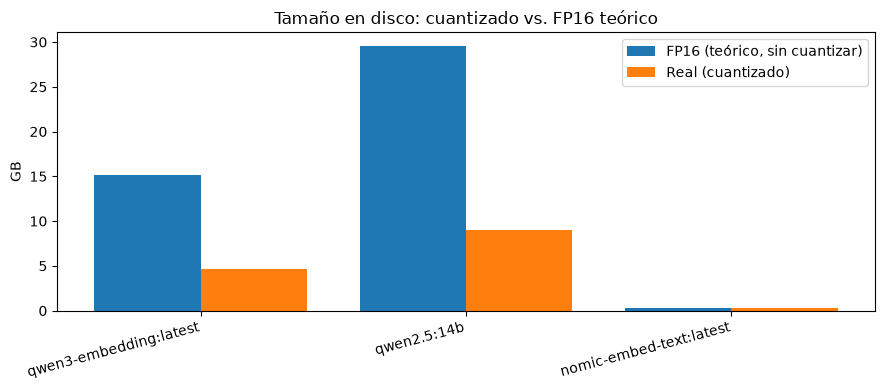

In [14]:
import matplotlib.pyplot as plt

nombres = [t[0] for t in tamanios]
reales = [t[2] for t in tamanios]
fp16 = [t[3] for t in tamanios]

x = range(len(nombres))
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar([i - 0.2 for i in x], fp16, width=0.4, label="FP16 (teórico, sin cuantizar)")
ax.bar([i + 0.2 for i in x], reales, width=0.4, label="Real (cuantizado)")
ax.set_xticks(list(x))
ax.set_xticklabels(nombres, rotation=15, ha="right")
ax.set_ylabel("GB")
ax.set_title("Tamaño en disco: cuantizado vs. FP16 teórico")
ax.legend()
plt.tight_layout()
plt.show()

---

## 4. Modelos desde Hugging Face

El catálogo oficial de Ollama es cómodo pero limitado — miles de modelos más viven en
[huggingface.co](https://huggingface.co), publicados directamente por la comunidad o por los
laboratorios que los entrenan. Para que Ollama pueda cargar uno, tiene que estar en formato
**GGUF** (el formato binario que usa `llama.cpp`, el motor sobre el que corre Ollama).

### El flujo, paso a paso

1. Buscar en Hugging Face, **filtrando por formato GGUF** (el filtro está en la barra lateral
   de la búsqueda de modelos).
2. Elegir la **cuantización** dentro del repo — un mismo repo GGUF suele traer varios archivos,
   uno por cada variante (`Q4_K_M`, `Q5_K_S`, `Q8_0`...), la misma nomenclatura que vimos en la
   Sección 2.
3. Copiar el identificador del repositorio — el patrón es `usuario/nombre-del-modelo`.
4. `ollama pull hf.co/usuario/nombre-del-modelo` — con el prefijo `hf.co/` delante, Ollama sabe
   que tiene que ir a buscarlo a Hugging Face en vez de a su propio catálogo.

No hay conversión manual, no hay que bajar el `.gguf` a mano y colocarlo en ninguna carpeta —
`hf.co/<repo>` funciona como si fuera el nombre de un modelo cualquiera de la librería oficial,
para `ollama pull`, `ollama run`, y también para `ollama.pull(...)`/`ollama.chat(...)` desde
Python.

**⏸ Pausa para navegar Hugging Face en vivo.** Antes de correr la celda siguiente: vamos a
buscar juntos en [huggingface.co/models](https://huggingface.co/models), filtrar por GGUF, y
elegir un modelo pequeño (idealmente **1B–3B parámetros** para que la descarga sea rápida
durante la clase). Se lee en la ficha del modelo: tamaño, licencia, y qué cuantizaciones GGUF
tiene disponibles — no todos los repos GGUF traen las mismas variantes.

Completá `HF_MODEL` con el identificador elegido (formato `usuario/repo`, sin el prefijo
`hf.co/` — la celda lo agrega) y corré las celdas siguientes.

In [15]:
# Completar con el repo elegido en la búsqueda, p.ej. "bartowski/Llama-3.2-3B-Instruct-GGUF"
HF_MODEL = None

In [16]:
# Paso 1: descargar
if HF_MODEL:
    modelo_hf = f"hf.co/{HF_MODEL}"
    print(f"Descargando {modelo_hf}...")
    for avance in ollama.pull(modelo_hf, stream=True):
        detalle = ""
        if avance.completed and avance.total:
            pct = 100 * avance.completed / avance.total
            detalle = f" — {pct:.0f}%"
        print(f"{avance.status}{detalle}")
else:
    print("HF_MODEL sin definir — completar con el repo elegido en la búsqueda en vivo.")

HF_MODEL sin definir — completar con el repo elegido en la búsqueda en vivo.


In [17]:
# Paso 2: probarlo con una única generación, para confirmar que quedó operativo
if HF_MODEL:
    respuesta = ollama.generate(model=modelo_hf, prompt="Decí 'hola' en una sola palabra.")
    print(f"Respuesta del modelo: {respuesta.response.strip()}")

---

## 5. Usar Ollama desde Python: `generate`, `chat` y `embed` desglosados

El paquete `ollama` expone tres funciones principales. Cada una sirve para un tipo de tarea
distinto, y las tres se ven usadas en algún punto del curso (`src/embeddings.py`, y las tareas
de NER/clasificación de los Bloques 2 y 4):

| Función            | Para qué sirve                                              | Devuelve                     |
|---------------------|--------------------------------------------------------------|-------------------------------|
| `ollama.generate()` | Completar un único prompt, sin historial de conversación     | Un texto (`response`)         |
| `ollama.chat()`     | Conversación con turnos (`user`/`assistant`/`system`)        | Un mensaje (`message.content`)|
| `ollama.embed()`    | Convertir texto en un vector numérico (no genera texto)      | Vector(es) (`embeddings`)     |

Ya usamos `ollama.embed()` en la Sección 1. Vamos ahora con `generate` y `chat`, empezando por
lo más simple posible.

In [18]:
# ollama.generate(): completar un único prompt
respuesta = ollama.generate(
    model="qwen2.5:14b",
    prompt="Completá la frase en una sola línea: 'Ollama corre modelos de lenguaje...'",
)

print(respuesta.response)

"Ollama corre modelos de lenguaje grandes como LLaMA."


### Qué hay adentro de la respuesta

`respuesta` no es solo el texto — es un objeto con metadata de rendimiento. Miremos todos los
campos antes de quedarnos solo con los que nos interesan.

In [19]:
# Todos los campos de la respuesta, salvo el propio texto (ya lo vimos arriba)
for campo, valor in respuesta.model_dump().items():
    if campo not in ("response", "context"):
        print(f"{campo:<22}{valor}")

model                 qwen2.5:14b
created_at            2026-07-21T15:52:09.435221425Z
done                  True
done_reason           stop
total_duration        4888359262
load_duration         3979761626
prompt_eval_count     50
prompt_eval_duration  167509000
eval_count            17
eval_duration         738948000
thinking              None
logprobs              None
image                 None
completed             None
total                 None


Dos pares de campos separan el trabajo en dos fases:

- **`prompt_eval_count` / `prompt_eval_duration`** — cuántos tokens tenía el prompt de entrada,
  y cuánto tardó el modelo en "leerlo" (esto se llama *prefill*).
- **`eval_count` / `eval_duration`** — cuántos tokens generó de respuesta, y cuánto tardó en
  generarlos uno por uno (esto se llama *decode*).

Son dos velocidades distintas — normalmente leer el prompt es mucho más rápido que generar,
porque leer se puede paralelizar y generar es secuencial (cada palabra depende de la anterior).
Calculamos las dos.

In [20]:
# Velocidad de lectura del prompt (prefill) vs. velocidad de generación (decode)
prefill_tokens_s = respuesta.prompt_eval_count / (respuesta.prompt_eval_duration / 1e9)
decode_tokens_s = respuesta.eval_count / (respuesta.eval_duration / 1e9)

print(f"Prompt:    {respuesta.prompt_eval_count} tokens leídos a {prefill_tokens_s:.0f} tokens/s")
print(f"Respuesta: {respuesta.eval_count} tokens generados a {decode_tokens_s:.1f} tokens/s")
print(
    "\nLa velocidad de generación (decode) es la que va a variar más entre laptops en el aula — "
    "quien tenga GPU va a ver un número bastante más alto que quien corra solo en CPU."
)

Prompt:    50 tokens leídos a 298 tokens/s
Respuesta: 17 tokens generados a 23.0 tokens/s

La velocidad de generación (decode) es la que va a variar más entre laptops en el aula — quien tenga GPU va a ver un número bastante más alto que quien corra solo en CPU.


### `ollama.chat()`: conversación con historial

`generate` no recuerda nada entre llamadas — cada `prompt` es independiente. `chat` en cambio
recibe una **lista de mensajes**, cada uno con un `role` (`system`, `user` o `assistant`), y el
modelo responde teniendo en cuenta todo lo anterior en esa lista. El "historial" no lo guarda
Ollama por vos: cada vez que llamás a `chat`, tenés que volver a mandar la lista completa,
incluyendo la respuesta anterior del modelo, para que "recuerde" de qué se venía hablando.

Vamos turno por turno.

In [21]:
# Turno 1: una lista con un único mensaje del usuario
historial = [
    {"role": "user", "content": "¿Qué es un embedding, en una frase?"},
]
respuesta1 = ollama.chat(model="qwen2.5:14b", messages=historial)
print(respuesta1.message.content)

Un embedding es una representación numérica de datos categóricos que captura relaciones semánticas entre los elementos.


In [22]:
# Para el turno 2, agregamos la respuesta del modelo Y la nueva pregunta al historial —
# si no agregáramos la respuesta anterior, el modelo no tendría forma de saber de qué se hablaba
historial.append({"role": "assistant", "content": respuesta1.message.content})
historial.append({"role": "user", "content": "¿Y en qué se diferencia de lo que hace un modelo generativo?"})

print(f"Historial ahora tiene {len(historial)} mensajes:")
for m in historial:
    print(f"  [{m['role']}] {m['content'][:60]}...")

Historial ahora tiene 3 mensajes:
  [user] ¿Qué es un embedding, en una frase?...
  [assistant] Un embedding es una representación numérica de datos categór...
  [user] ¿Y en qué se diferencia de lo que hace un modelo generativo?...


In [23]:
# Turno 2: se manda TODO el historial de nuevo, no solo el mensaje nuevo
respuesta2 = ollama.chat(model="qwen2.5:14b", messages=historial)
print(respuesta2.message.content)

Mientras que el embedding convierte datos categóricos en vectores densos para capturar similitudes y relaciones, un modelo generativo aprende la distribución de los datos para poder crear nuevos ejemplos similares a partir de esa distribución. En otras palabras, los embeddings son representaciones de datos existentes, mientras que los modelos generativos crean nuevo contenido basado en patrones aprendidos.


### `system` prompt: instrucciones que se aplican a toda la conversación

Un mensaje con `role: "system"` no es una pregunta del usuario — es una instrucción de
comportamiento que el modelo aplica a lo largo de todo el intercambio. Es la base de tareas
como el NER zero-shot del Bloque 2: en vez de entrenar un modelo específico para reconocer
entidades de un dominio (tarjetas, criptomonedas, alias), le damos a un modelo generativo
genérico un `system` prompt que lo instruye a comportarse como un extractor de entidades.

In [24]:
# Definimos el system prompt y el post de ejemplo por separado, antes de mandarlos
system_prompt = (
    "Sos un extractor de entidades para foros underground. Dado un post, devolvé SOLO "
    "las entidades de tipo TARJETA, CRIPTOMONEDA o ALIAS que encuentres, una por línea, "
    "formato 'TIPO: valor'. Si no hay ninguna, respondé 'ninguna'."
)

post_ejemplo = "vendo dumps track1+2 validados, pago en BTC, contactar a darkuser99 por PM"
print(post_ejemplo)

vendo dumps track1+2 validados, pago en BTC, contactar a darkuser99 por PM


In [25]:
# El system prompt va PRIMERO en la lista de mensajes, antes del mensaje del usuario
respuesta_ner = ollama.chat(
    model="qwen2.5:14b",
    messages=[
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": post_ejemplo},
    ],
)
print(respuesta_ner.message.content)

CRIPTOMONEDA: BTC
ALIAS: darkuser99


### Streaming: respuestas que se muestran a medida que se generan

Igual que `ollama.pull(...)`, tanto `generate` como `chat` aceptan `stream=True` y devuelven un
generador en vez de la respuesta completa de una vez. Es puramente una cuestión de UX — el
modelo tarda lo mismo en generar el texto completo, pero con streaming el usuario ve las
palabras aparecer una por una en vez de esperar en silencio hasta el final. Es lo que hacen
ChatGPT y el resto de las interfaces de chat.

In [26]:
# Sin streaming: la celda se queda "colgada" hasta que el modelo termina toda la respuesta
import time

inicio = time.time()
respuesta_completa = ollama.chat(
    model="qwen2.5:14b",
    messages=[{"role": "user", "content": "Contá hasta 5, una palabra por línea."}],
)
print(f"(nada se vio en pantalla hasta acá — {time.time() - inicio:.1f}s después)")
print(respuesta_completa.message.content)

(nada se vio en pantalla hasta acá — 0.8s después)
Uno
Dos
Tres
Cuatro
Cinco


In [27]:
# Con streaming: el mismo prompt, pero cada chunk se imprime apenas llega
for chunk in ollama.chat(
    model="qwen2.5:14b",
    messages=[{"role": "user", "content": "Contá hasta 5, una palabra por línea."}],
    stream=True,
):
    print(chunk.message.content, end="", flush=True)
print()  # salto de línea final

Uno

Dos

T

res

Cu

atro

C

in

co

### `ollama.embed()` otra vez: comparar textos por similitud

Ya vimos `embed` generando un solo vector. La razón por la que sirve es la que se explicó en la
presentación: textos de significado parecido producen vectores cercanos entre sí. "Cercano" acá
se mide con **similitud coseno** — 1.0 significa vectores idénticos en dirección, 0.0 significa
completamente distintos.

In [28]:
import numpy as np

def similitud_coseno(a, b):
    a, b = np.array(a), np.array(b)
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))

posts = [
    "vendo dumps de tarjetas validadas, alta tasa de acierto",           # tema: carding
    "compro cvv frescos, pago en bitcoin, contactame por pm",             # tema: carding
    "tutorial de phishing paso a paso para principiantes",                # tema: phishing
]
print(f"{len(posts)} posts de ejemplo, dos de carding y uno de phishing.")

3 posts de ejemplo, dos de carding y uno de phishing.


In [29]:
# embed() acepta una lista completa en una sola llamada, no hace falta una petición por texto
resp = ollama.embed(model="qwen3-embedding", input=posts)
vectores = resp.embeddings

print(f"{len(vectores)} vectores devueltos, de {len(vectores[0])} dimensiones cada uno.")

3 vectores devueltos, de 4096 dimensiones cada uno.


In [30]:
# Similitud coseno entre cada par de posts
for i in range(len(posts)):
    for j in range(i + 1, len(posts)):
        sim = similitud_coseno(vectores[i], vectores[j])
        print(f"[{i}] vs [{j}]: {sim:.3f}")

[0] vs [1]: 0.701
[0] vs [2]: 0.547
[1] vs [2]: 0.517


En números es un poco abstracto — lo mismo, como mapa de calor: cada celda es la similitud
entre el post de esa fila y el de esa columna (la diagonal es siempre 1.0, un post comparado
consigo mismo).

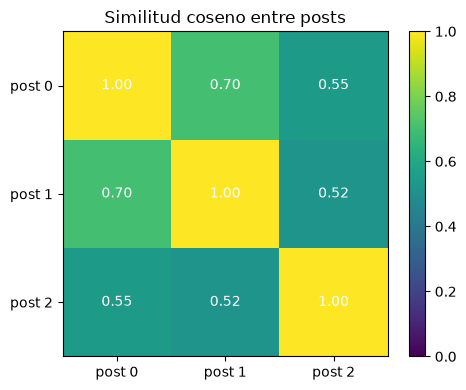

Los dos posts de carding (0 y 1) quedan más cerca entre sí que cualquiera de los dos respecto al post de phishing (2) — es exactamente el mecanismo que se usa para clustering de usuarios en el Bloque 2.


In [31]:
matriz_similitud = np.array([[similitud_coseno(vectores[i], vectores[j]) for j in range(3)] for i in range(3)])

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(matriz_similitud, cmap="viridis", vmin=0, vmax=1)
ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels([f"post {i}" for i in range(3)])
ax.set_yticklabels([f"post {i}" for i in range(3)])
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{matriz_similitud[i, j]:.2f}", ha="center", va="center", color="white")
ax.set_title("Similitud coseno entre posts")
fig.colorbar(im)
plt.tight_layout()
plt.show()

print(
    "Los dos posts de carding (0 y 1) quedan más cerca entre sí que cualquiera de los dos "
    "respecto al post de phishing (2) — es exactamente el mecanismo que se usa para "
    "clustering de usuarios en el Bloque 2."
)

---

## 6. Ajustar la generación: el diccionario `options`

Además de elegir **qué** modelo usar, `ollama.chat()` y `ollama.generate()` aceptan un
parámetro `options`: un diccionario de hiperparámetros de inferencia que se aplican **por
llamada**, sin tocar el modelo en disco — no hay que rebajarlo ni recargarlo, el cambio es
inmediato en la siguiente petición.

Los más relevantes:

| Parámetro | Qué controla | Por defecto |
|---|---|---|
| `temperature` | Aleatoriedad al elegir la siguiente palabra (0 = determinista, 1+ = creativo) | 0.8 |
| `num_ctx` | Ventana de contexto: cuántos tokens (prompt + historial + salida) puede "ver" el modelo a la vez | 4096 |
| `num_predict` | Máximo de tokens a generar en la respuesta | -1 (sin límite) |
| `seed` | Semilla aleatoria, para reproducibilidad | aleatoria |

Vamos uno por uno: `temperature`, `num_predict`, y por último — el que más importa para quien
va a trabajar con agentes o RAG (Bloque 4) — `num_ctx`.

### `temperature`: determinismo vs. creatividad

Con `temperature=0` el modelo elige siempre el token más probable en cada paso — dos corridas
del mismo prompt deberían dar (casi) la misma respuesta. Probamos con un prompt de una sola
palabra... y con uno más abierto, para ver la diferencia.

In [32]:
# Con una respuesta de una sola palabra muy obvia, ni siquiera temperature alta cambia nada:
# la distribución de probabilidad está tan concentrada en un token que no hay margen para variar
prompt_cerrado = "Nombrá un animal, una sola palabra."

for t in (0, 1.5):
    r = ollama.generate(model="qwen2.5:14b", prompt=prompt_cerrado, options={"temperature": t})
    print(f"temperature={t}: '{r.response.strip()}'")

temperature=0: 'León'


temperature=1.5: 'León'


Para que la temperatura tenga margen real para variar, hace falta un prompt donde haya
varias continuaciones igual de razonables — por ejemplo, completar una historia.

In [33]:
prompt_abierto = "Continuá en una frase corta: 'Ayer caminaba por la calle cuando de repente'"

print("temperature=0 (determinista) — 2 corridas:")
for _ in range(2):
    r = ollama.generate(model="qwen2.5:14b", prompt=prompt_abierto, options={"temperature": 0, "num_predict": 25})
    print(f"  '{r.response.strip()}'")

temperature=0 (determinista) — 2 corridas:


  '"Ayer caminaba por la calle cuando de repente escuché mi nombre."'


  '"Ayer caminaba por la calle cuando de repente escuché mi nombre."'


In [34]:
print("temperature=1.3 (creativo) — 2 corridas:")
for _ in range(2):
    r = ollama.generate(model="qwen2.5:14b", prompt=prompt_abierto, options={"temperature": 1.3, "num_predict": 25})
    print(f"  '{r.response.strip()}'")

print(
    "\nCon temperature=0 las dos corridas salen iguales o casi. Con temperature alta divergen. "
    "Por eso NER/clasificación (queremos consistencia) va con temperature baja, y generación "
    "creativa va con temperature alta."
)

temperature=1.3 (creativo) — 2 corridas:


  '"Ayer caminaba por la calle cuando de repente escuché mi nombre."'


  '"Ayer caminaba por la calle cuando de repente escuché mi nombre."'

Con temperature=0 las dos corridas salen iguales o casi. Con temperature alta divergen. Por eso NER/clasificación (queremos consistencia) va con temperature baja, y generación creativa va con temperature alta.


### `num_predict`: cortar la respuesta a un largo máximo

Sirve para acotar cuánto puede llegar a generar el modelo — útil si solo necesitás una
respuesta corta y no querés esperar (o pagar cómputo) por una larga. El campo `done_reason` de
la respuesta indica si el modelo terminó naturalmente (`stop`) o si lo cortamos nosotros
(`length`).

In [35]:
prompt_largo = "Escribí un párrafo corto sobre el mar."

r_corta = ollama.generate(model="qwen2.5:14b", prompt=prompt_largo, options={"num_predict": 12})
print(f"num_predict=12 → done_reason='{r_corta.done_reason}', {r_corta.eval_count} tokens generados")
print(f"'{r_corta.response.strip()}'")

num_predict=12 → done_reason='length', 12 tokens generados
'El mar es una vasta extensión de agua sal'


In [36]:
r_completa = ollama.generate(model="qwen2.5:14b", prompt=prompt_largo, options={"num_predict": -1})
print(f"num_predict=-1 → done_reason='{r_completa.done_reason}', {r_completa.eval_count} tokens generados")
print(f"'{r_completa.response.strip()}'")

num_predict=-1 → done_reason='stop', 179 tokens generados
'El mar es una vasta extensión de agua salada que cubre gran parte de la superficie terrestre. Su belleza y misterio han cautivado a los humanos durante siglos, siendo tanto un medio de vida como un lugar de recreación y descubrimiento. Las olas danzan bajo la luz del sol mientras reflejan una gama infinita de colores que van desde el azul profundo hasta tonalidades brillantes en días soleados. En sus aguas viven una diversidad inigualable de vida marina, desde diminutos organismos planctónicos hasta grandes ballenas. Además de ser un hogar para la biodiversidad, el mar desempeña un papel crucial en el equilibrio del clima global y el ciclo de nutrientes en nuestro planeta.'


### `num_ctx`: el parámetro que más le va a importar a quien monte agentes

`num_ctx` es la ventana de contexto: cuántos tokens puede tener en cuenta el modelo a la vez,
sumando el prompt, todo el historial de `chat()` y la respuesta que va generando. Si ese total
supera `num_ctx`, Ollama **descarta silenciosamente lo más viejo** — no tira ningún error, el
modelo simplemente deja de "recordar" el principio de la conversación o los primeros documentos
que le pasaste.

Esto no es un detalle menor para quien va a construir agentes o RAG (Bloque 4): un agente que
arrastra un historial largo de pasos, o un pipeline de RAG que mete varios documentos de
contexto en el prompt, se queda corto muy rápido con el valor por defecto.

Con `ollama ps` (CLI) se puede ver, mientras el modelo está cargado, con cuánto contexto está
corriendo ahora mismo. Lo comparamos antes y después de pedir un `num_ctx` más grande.

In [37]:
# Contexto por defecto: una llamada sin 'options'
ollama.generate(model="qwen2.5:14b", prompt="hola")

estado = subprocess.run(["ollama", "ps"], capture_output=True, text=True)
print("Antes (num_ctx por defecto):")
print(estado.stdout)

Antes (num_ctx por defecto):
NAME           ID              SIZE      PROCESSOR    CONTEXT    UNTIL              
qwen2.5:14b    7cdf5a0187d5    9.5 GB    100% GPU     4096       4 minutes from now    



In [38]:
# Ahora pedimos explícitamente el doble de contexto
ollama.generate(model="qwen2.5:14b", prompt="hola", options={"num_ctx": 8192})

estado = subprocess.run(["ollama", "ps"], capture_output=True, text=True)
print("Después (num_ctx=8192):")
print(estado.stdout)

print(
    "La columna CONTEXT pasa de 4096 a 8192, y SIZE sube un poco — más contexto "
    "cargado en RAM/VRAM tiene un costo, no es gratis subirlo 'por las dudas'."
)

Después (num_ctx=8192):
NAME           ID              SIZE     PROCESSOR    CONTEXT    UNTIL              
qwen2.5:14b    7cdf5a0187d5    10 GB    100% GPU     8192       4 minutes from now    

La columna CONTEXT pasa de 4096 a 8192, y SIZE sube un poco — más contexto cargado en RAM/VRAM tiene un costo, no es gratis subirlo 'por las dudas'.


**Regla práctica:** dejar `num_ctx` en su valor por defecto salvo que se sepa que hace falta
más — conversaciones o cadenas de razonamiento de un agente que se alargan, RAG con varios
documentos largos como contexto. Subirlo de más "por las dudas" en una máquina con poca VRAM
puede hacer que el modelo ni siquiera cargue en GPU y caiga a CPU, mucho más lento.

---

## 7. A jugar

Con esto queda cubierto todo lo que se explicó en la presentación de este bloque: instalación,
gestión de modelos (librería oficial y Hugging Face), las tres funciones principales del
cliente Python, y los parámetros de generación (`options`, `num_ctx`). El resto del tiempo es
para probar con su propia máquina.

Ideas para experimentar (no hace falta hacerlas todas, ni en este orden):

- **Buscar y traer un modelo propio de Hugging Face** — repetir la Sección 4 con un modelo
  distinto, elegido por ustedes. Filtren por tamaño chico (1B–3B) si quieren que la descarga
  sea rápida.
- **Medir tokens/s en su hardware** — repetir las celdas de la Sección 5 que calculan
  tokens/segundo (prefill y decode), y comparar entre compañeros. Quien tenga GPU en su
  portátil personal debería ver una diferencia notable contra quien corra en CPU.
- **Jugar con streaming** — probar `ollama.chat(..., stream=True)` con un prompt que pida una
  respuesta larga (un resumen, una lista de 20 ítems) y ver cómo aparece el texto.
- **Cambiar el `system` prompt del NER** — la celda de extracción de entidades de la Sección 5
  usa tres tipos de entidad fijos (TARJETA, CRIPTOMONEDA, ALIAS). Prueben agregar un cuarto tipo
  propio y ver si el modelo lo respeta.
- **Comparar dos modelos con el mismo prompt** — si bajaron un modelo de Hugging Face, correr el
  mismo `prompt` con `ollama.generate()` en `qwen2.5:14b` y en el modelo nuevo, y comparar
  calidad y velocidad.
- **Jugar con `options`** — repetir la celda de `temperature` con valores intermedios (0.3, 0.7,
  1.0) y ver en qué punto empiezan a divergir las respuestas. Si van a trabajar con agentes,
  probar también subir `num_ctx` y mirar el impacto en `ollama ps` (columna SIZE) en su propia
  máquina.

Si algo no anda — el error más común es el servidor de Ollama caído (`ollama serve` en una
terminal aparte lo levanta) — es buen momento para resolverlo con ayuda, antes de los casos
prácticos del Bloque 5.